In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/rtl.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))

# فصل ۶ — تکنیک‌های یادگیری تجمیعی (Ensemble Learning)
## درس ۹: درخت‌های فوق‌العاده تصادفی (ExtraTrees) و «تنوع» (Diversity)

**ایدهٔ اصلی:** ExtraTrees نسبت به Random Forest تصادفی‌سازی *بیشتری* وارد می‌کند تا **تنوع** بین درخت‌ها افزایش یابد. این تنوع می‌تواند همبستگی خطاها را کاهش دهد، و در نتیجه واریانس مدل تجمیعی کم‌تر شده و گاهی تعمیم بهتری به‌دست آید—به‌خصوص در مسائل جدولی (tabular) پرنویز یا با واریانس بالا.

### اهداف یادگیری
در پایان این درس باید بتوانید:
- تفاوت‌های ExtraTrees و Random Forest را توضیح دهید (bootstrap در برابر استفاده از کل داده، آستانه‌های تصادفی).
- نشان دهید چرا خطای یک ensemble به هر دو عامل **قدرت** (strength/دقت پایه) و **همبستگی** (correlation/تنوع) وابسته است.
- تنوع را با معیارهای عملی اندازه‌گیری کنید (عدم توافق جفتی، همبستگی پیش‌بینی‌های درخت‌ها).
- هایپرپارامترهایی را تنظیم کنید که موازنهٔ بایاس/واریانس و تنوع را تغییر می‌دهند.
- برای طبقه‌بندی و رگرسیون، pipelineهای قابل‌تکرار (reproducible) با ExtraTrees بسازید.


## ۱) چرا «تنوع» در ensemble مهم است؟

فرض کنید $M$ پیش‌بین پایه $h_1(x),\dots,h_M(x)$ داریم و میانگین آن‌ها را به‌عنوان خروجی ensemble می‌گیریم:

$$
\bar h(x)=\frac{1}{M}\sum_{m=1}^M h_m(x).
$$

اگر هر $h_m$ دقت مشابهی داشته باشد اما اشتباهات متفاوتی مرتکب شود، میانگین/رأی‌گیری می‌تواند خطاها را تا حدی خنثی کند. یک محاسبهٔ واریانس این موضوع را دقیق می‌کند.

### ۱.۱ واریانس میانگین ensemble (استخراج کلیدی)

برای یک ورودی ثابت $x$، فرض کنید هر $h_m(x)$ یک متغیر تصادفی باشد و:
- $\operatorname{Var}(h_m(x))=\sigma^2$ (واریانس یکسان)،
- $\operatorname{Corr}(h_i(x),h_j(x))=\rho$ برای $i\neq j$ (همبستگی جفتی یکسان).

در این صورت:

$$
\operatorname{Var}(\bar h(x))
=\operatorname{Var}\left(\frac{1}{M}\sum_{m=1}^M h_m(x)\right)
=\frac{1}{M^2}\left(\sum_{m=1}^M \sigma^2 + \sum_{i\neq j} \rho\sigma^2\right)
$$

و چون $M(M-1)$ جملهٔ خارج از قطر داریم:

$$
\operatorname{Var}(\bar h(x))
=\sigma^2\left(\frac{1}{M} + \rho\,\frac{M-1}{M}\right).
$$

**برداشت**
- اگر $\rho=0$ باشد، واریانس مانند $\sigma^2/M$ کاهش می‌یابد.
- اگر $\rho>0$ باشد، با بزرگ شدن $M$ یک «کف» تقریبی $\rho\sigma^2$ باقی می‌ماند.
- کاهش همبستگی $\rho$ (یعنی افزایش تنوع) می‌تواند به اندازهٔ افزایش تعداد درخت‌ها مهم باشد.

> ExtraTrees عمدتاً برای کاهش $\rho$ طراحی شده است؛ با تصادفی‌سازیِ بیشتر در انتخاب splitها.


## ۲) Random Forest در برابر ExtraTrees

هر دو روش تعداد زیادی درخت تصمیم می‌سازند و سپس آن‌ها را تجمیع می‌کنند. تفاوت اصلی در این است که **تصادفی‌سازی چگونه وارد می‌شود**.

### ۲.۱ تصادفی‌سازی در Random Forest (RF)
RF معمولاً از این دو منبع تصادفی‌سازی استفاده می‌کند:
1. **Bootstrap sampling**: هر درخت روی یک نمونهٔ بوت‌استرپ (نمونه‌گیری با جایگذاری) آموزش می‌بیند.
2. **Random feature subspace**: در هر گره، تنها یک زیرمجموعهٔ تصادفی از ویژگی‌ها (`max_features`) بررسی می‌شود و سپس بهترین split از میان آن‌ها انتخاب می‌گردد.

### ۲.۲ تصادفی‌سازی در ExtraTrees
ExtraTrees (درخت‌های فوق‌العاده تصادفی) معمولاً:
1. **به‌صورت پیش‌فرض bootstrap ندارد** (`bootstrap=False`) و هر درخت کل دادهٔ آموزش را می‌بیند (می‌توان bootstrap را فعال کرد).
2. **آستانه‌های تصادفی**: در هر گره، مانند RF تعدادی ویژگی انتخاب می‌شود، اما برای هر ویژگی یک یا چند آستانهٔ *تصادفی* نمونه‌گیری می‌شود و سپس بهترین گزینه از میان کاندیدهای تصادفی انتخاب می‌گردد.

روند ساده‌شدهٔ هر گره:
- $K$ ویژگی از میان $d$ ویژگی انتخاب کن.
- برای هر ویژگی منتخب $j$، یک آستانهٔ $\theta_j$ به‌صورت یکنواخت از بازهٔ مقادیر همان گره نمونه‌گیری کن.
- کاهش ناخالصی (impurity decrease) را برای هر $(j,\theta_j)$ محاسبه کن.
- بهترین کاندید را انتخاب کن.

### ۲.۳ شهود بایاس–واریانس
- تصادفی‌سازی بیشتر معمولاً **بایاس را کمی افزایش** می‌دهد (splitها کمتر «بهینه» می‌شوند).
- اما می‌تواند **واریانس را زیاد کاهش** دهد چون همبستگی درخت‌ها کم می‌شود.
- نتیجهٔ نهایی می‌تواند تعمیم بهتر باشد، وقتی واریانس عامل غالب است (نویز بالا، ویژگی‌های تکراری، تعاملات پیچیده).

در عمل، ExtraTrees اغلب درخت‌ها را سریع‌تر آموزش می‌دهد (جست‌وجوی split ارزان‌تر) و روی داده‌های جدولی می‌تواند بسیار رقابتی باشد.


## ۳) نگاه قدرت–همبستگی (Strength–Correlation)

یک مدل ذهنی مفید (در تحلیل Random Forest هم رایج است) این است که خطای ensemble به دو عامل وابسته است:
- **قدرت (strength)**: کیفیت هر درخت به‌تنهایی،
- **همبستگی (correlation)**: شباهت خطاهای درخت‌ها.

نتیجهٔ واریانس بخش ۱ نشان می‌دهد:
- قوی‌تر کردن درخت‌ها غالباً با splitهای کم‌تصادف‌تر همراه است و می‌تواند همبستگی را بالا ببرد.
- متنوع‌تر کردن درخت‌ها همبستگی را کاهش می‌دهد، اما اگر تصادفی‌سازی بیش از حد شود، درخت‌ها ضعیف می‌شوند.

ExtraTrees تلاش می‌کند تعادلی ایجاد کند: درخت‌ها همچنان بر اساس معیار ناخالصی greedy هستند، اما تصادفی‌سازیِ آستانه‌ها تنوع را بالا می‌برد.

### ۳.۱ یادآوری تجزیهٔ بایاس–واریانس (برای رگرسیون)
برای خطای مربعی، اگر $y=f(x)+\varepsilon$ و $\mathbb{E}[\varepsilon]=0$ و $\operatorname{Var}(\varepsilon)=\sigma_\varepsilon^2$، داریم:

$$
\mathbb{E}\big[(\hat f(x)-y)^2\big]
= \underbrace{\big(\mathbb{E}[\hat f(x)]-f(x)\big)^2}_{\text{Bias}^2}
+ \underbrace{\operatorname{Var}(\hat f(x))}_{\text{Variance}}
+ \underbrace{\sigma_\varepsilon^2}_{\text{Noise}}.
$$

ExtraTrees عمدتاً روی **واریانس** اثر می‌گذارد (با کاهش همبستگی)، حتی اگر بایاس کمی افزایش یابد.

### ۳.۲ معیارهای تنوع که در این درس محاسبه می‌کنیم
- **عدم توافق جفتی** (طبقه‌بندی): $\Pr(\hat y_i \neq \hat y_j)$ روی مجموعهٔ اعتبارسنجی/آزمون.
- **همبستگی پیش‌بینی‌ها** (رگرسیون): $\operatorname{Corr}(\hat y_i,\hat y_j)$.
- همچنین یک نمودار سادهٔ «قدرت در برابر تنوع» برای دیدن trade-off.


In [2]:
# Imports and reproducibility
import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix,
    mean_squared_error, r2_score
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def safe_read_csv(rel_path):
    """Read a CSV via a repo-relative path (as specified in your project structure)."""
    p = Path(rel_path)
    if not p.exists():
        raise FileNotFoundError(
            f"Could not find {p}.\n"
            "Expected to run this notebook inside Tutorials/... so the relative path points to Datasets/..." 
        )
    return pd.read_csv(p)

def summarize_df(df, target=None, n=5):
    display(df.head(n))
    print("\nShape:", df.shape)
    if target is not None and target in df.columns:
        print("\nTarget distribution:")
        display(df[target].value_counts().head(20))


In [3]:
# Diversity helpers (simple and practical)

def _sample_tree_indices(n_trees, max_pairs=2500, random_state=42):
    """Return indices to form random pairs without O(n^2) blow-up."""
    rng = np.random.default_rng(random_state)
    # sample pairs as (i,j) with i<j
    pairs = []
    for _ in range(max_pairs):
        i = rng.integers(0, n_trees)
        j = rng.integers(0, n_trees)
        if i == j:
            continue
        if i > j:
            i, j = j, i
        pairs.append((int(i), int(j)))
    return pairs

def classification_disagreement(ensemble, X, max_pairs=2000, random_state=42):
    """Average pairwise disagreement across trees on X."""
    # Works for sklearn forests with estimators_
    trees = getattr(ensemble, "estimators_", None)
    if trees is None:
        raise ValueError("Model has no estimators_ (did you fit it?)")
    n_trees = len(trees)
    pairs = _sample_tree_indices(n_trees, max_pairs=max_pairs, random_state=random_state)

    preds = [t.predict(X) for t in trees]  # list of (n_samples,)
    preds = np.asarray(preds)              # (n_trees, n_samples)

    dis = []
    for i, j in pairs:
        dis.append(np.mean(preds[i] != preds[j]))
    return float(np.mean(dis))

def regression_prediction_corr(ensemble, X, max_pairs=2000, random_state=42):
    """Average pairwise Pearson correlation of tree predictions on X."""
    trees = getattr(ensemble, "estimators_", None)
    if trees is None:
        raise ValueError("Model has no estimators_ (did you fit it?)")
    n_trees = len(trees)
    pairs = _sample_tree_indices(n_trees, max_pairs=max_pairs, random_state=random_state)

    preds = [t.predict(X) for t in trees]
    preds = np.asarray(preds)  # (n_trees, n_samples)

    corrs = []
    for i, j in pairs:
        a, b = preds[i], preds[j]
        # Handle constant predictions (rare but possible)
        if np.std(a) < 1e-12 or np.std(b) < 1e-12:
            continue
        corrs.append(np.corrcoef(a, b)[0, 1])
    return float(np.mean(corrs)) if len(corrs) else float("nan")

def plot_metric_bars(names, values, title, ylabel):
    plt.figure()
    plt.bar(names, values)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()


## ۴) آزمایش ۱ — طبقه‌بندی دودویی (diabetes.csv)

در این بخش Random Forest و ExtraTrees را روی دیتاست **diabetes.csv** (طبق ساختار repo شما) مقایسه می‌کنیم.

اهداف:
1. مقایسهٔ Accuracy و F1.
2. اندازه‌گیری **تنوع** با عدم توافق جفتی بین درخت‌ها.
3. مشاهدهٔ اثر `max_features` و `min_samples_leaf` روی تعادل قدرت–تنوع.

نکته‌ها:
- این دیتاست ستون‌های عددی دارد و هدف `classification` دودویی است.
- پیش‌پردازش حداقلی نگه داشته می‌شود: impute برای مقادیر گمشده (در صورت وجود).


Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'classification']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,classification
0,6,148,72,35,0,33.6,0.627,50,Diabetic
1,1,85,66,29,0,26.6,0.351,31,Non-Diabetic
2,8,183,64,0,0,23.3,0.672,32,Diabetic
3,1,89,66,23,94,28.1,0.167,21,Non-Diabetic
4,0,137,40,35,168,43.1,2.288,33,Diabetic



Shape: (768, 9)

Target distribution:


classification
Non-Diabetic    500
Diabetic        268
Name: count, dtype: int64

,model,accuracy,f1,roc_auc
0,RandomForest,0.770833,0.645161,0.811463
1,ExtraTrees,0.755208,0.611570,0.793791


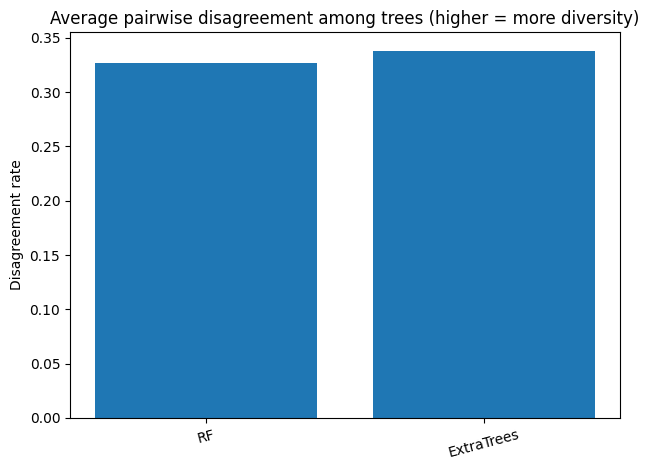

RF disagreement: 0.32709170433617946
ExtraTrees disagreement: 0.33819374686087394


In [4]:
# Load dataset (Classification: diabetes.csv)
df = safe_read_csv("../../../Datasets/Classification/diabetes.csv")
target = "classification"

print("Columns:", df.columns.tolist())
summarize_df(df, target=target, n=5)

X = df.drop(columns=[target])
y = df[target]

# Basic split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

# Simple preprocessing (mostly for safety; trees can handle unscaled numeric features)
num_cols = X.columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            # scaler is optional for trees; keep it off by default:
            # ("scaler", StandardScaler()),
        ]), num_cols),
    ],
    remainder="drop"
)

rf = RandomForestClassifier(
    n_estimators=400,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    max_features="sqrt",
    min_samples_leaf=1,
    bootstrap=True,
)

et = ExtraTreesClassifier(
    n_estimators=400,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    max_features="sqrt",
    min_samples_leaf=1,
    bootstrap=False,  # default behavior
)

rf_pipe = Pipeline([("prep", preprocess), ("model", rf)])
et_pipe = Pipeline([("prep", preprocess), ("model", et)])

rf_pipe.fit(X_train, y_train)
et_pipe.fit(X_train, y_train)

def eval_clf(pipe, X_te, y_te, name):
    pred = pipe.predict(X_te)
    proba = None
    if hasattr(pipe[-1], "predict_proba"):
        proba = pipe.predict_proba(X_te)
    acc = accuracy_score(y_te, pred)
    f1 = f1_score(y_te, pred, pos_label="Diabetic") if "Diabetic" in np.unique(y_te) else f1_score(y_te, pred, average="macro")
    auc = None
    if proba is not None and proba.shape[1] == 2:
        # Make sure we map to the positive class probability:
        classes = pipe[-1].classes_
        pos_idx = int(np.where(classes == "Diabetic")[0][0]) if "Diabetic" in classes else 1
        auc = roc_auc_score((y_te == (classes[pos_idx])).astype(int), proba[:, pos_idx])
    return {"model": name, "accuracy": acc, "f1": f1, "roc_auc": auc}

rf_metrics = eval_clf(rf_pipe, X_test, y_test, "RandomForest")
et_metrics = eval_clf(et_pipe, X_test, y_test, "ExtraTrees")

metrics_df = pd.DataFrame([rf_metrics, et_metrics])
display(metrics_df)

# Diversity (pairwise disagreement of fitted trees)
X_test_p = rf_pipe.named_steps["prep"].transform(X_test)

rf_dis = classification_disagreement(rf_pipe.named_steps["model"], X_test_p, max_pairs=2000, random_state=RANDOM_STATE)
et_dis = classification_disagreement(et_pipe.named_steps["model"], X_test_p, max_pairs=2000, random_state=RANDOM_STATE)

plot_metric_bars(
    ["RF", "ExtraTrees"],
    [rf_dis, et_dis],
    title="Average pairwise disagreement among trees (higher = more diversity)",
    ylabel="Disagreement rate"
)

print("RF disagreement:", rf_dis)
print("ExtraTrees disagreement:", et_dis)


### ۴.۱ هایپرپارامترهایی که تنوع را کنترل می‌کنند

دو اهرم مهم:

1) `max_features` (اندازهٔ زیرمجموعهٔ ویژگی‌ها)
- کوچک‌تر شدن `max_features` → تصادفی‌سازی بیشتر در هر split → معمولاً تنوع بیشتر.
- اگر خیلی کوچک شود، درخت‌ها ضعیف می‌شوند و بایاس بالا می‌رود.

2) `min_samples_leaf`
- بزرگ‌تر شدن برگ‌ها، عمق درخت را کمتر کرده و overfitting را کاهش می‌دهد.
- اغلب واریانس را کم می‌کند و می‌تواند ساختار همبستگی را نیز تغییر دهد.

در یک sweep سبک، هم‌زمان:
- Accuracy/F1 (تقریب قدرت)،
- Disagreement (تقریب تنوع)
را گزارش می‌کنیم.


,model_type,max_features,min_samples_leaf,accuracy,f1,disagreement
20,et,0.5,5,0.770833,0.600000,0.277356
14,et,sqrt,5,0.765625,0.536082,0.270938
18,et,0.5,1,0.765625,0.640000,0.324112
23,et,0.3,5,0.765625,0.536082,0.270938
13,et,sqrt,2,0.760417,0.596491,0.348352
22,et,0.3,2,0.760417,0.596491,0.348352
15,et,0.7,1,0.755208,0.617886,0.319671
16,et,0.7,2,0.755208,0.605042,0.326891
17,et,0.7,5,0.755208,0.584071,0.272378
19,et,0.5,2,0.755208,0.598291,0.332138


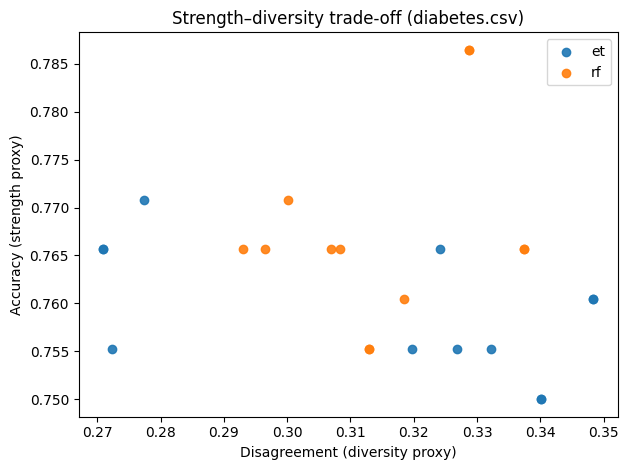

In [5]:
from itertools import product

def run_clf_sweep(X_train, X_test, y_train, y_test, max_features_list, min_leaf_list, model_type="rf"):
    rows = []
    for mf, leaf in product(max_features_list, min_leaf_list):
        if model_type == "rf":
            model = RandomForestClassifier(
                n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1,
                max_features=mf, min_samples_leaf=leaf, bootstrap=True
            )
        else:
            model = ExtraTreesClassifier(
                n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1,
                max_features=mf, min_samples_leaf=leaf, bootstrap=False
            )

        pipe = Pipeline([("prep", preprocess), ("model", model)])
        pipe.fit(X_train, y_train)
        met = eval_clf(pipe, X_test, y_test, f"{model_type}:{mf}:{leaf}")
        X_test_p = pipe.named_steps["prep"].transform(X_test)
        dis = classification_disagreement(pipe.named_steps["model"], X_test_p, max_pairs=1500, random_state=RANDOM_STATE)

        rows.append({
            "model_type": model_type,
            "max_features": mf,
            "min_samples_leaf": leaf,
            "accuracy": met["accuracy"],
            "f1": met["f1"],
            "disagreement": dis
        })
    return pd.DataFrame(rows)

max_features_list = ["sqrt", 0.7, 0.5, 0.3]
min_leaf_list = [1, 2, 5]

rf_sweep = run_clf_sweep(X_train, X_test, y_train, y_test, max_features_list, min_leaf_list, model_type="rf")
et_sweep = run_clf_sweep(X_train, X_test, y_train, y_test, max_features_list, min_leaf_list, model_type="et")

sweep = pd.concat([rf_sweep, et_sweep], ignore_index=True)
display(sweep.sort_values(["model_type", "accuracy"], ascending=[True, False]).head(12))

# Visualize strength vs diversity (simple scatter)
plt.figure()
for mt, g in sweep.groupby("model_type"):
    plt.scatter(g["disagreement"], g["accuracy"], label=mt, alpha=0.9)
plt.xlabel("Disagreement (diversity proxy)")
plt.ylabel("Accuracy (strength proxy)")
plt.title("Strength–diversity trade-off (diabetes.csv)")
plt.legend()
plt.tight_layout()
plt.show()


## ۵) آزمایش ۲ — طبقه‌بندی چندکلاسه (iris.csv)

مسائل چندکلاسه اغلب نشان می‌دهند که چگونه `max_features` و تصادفی‌سازی splitها روی:
- مرزهای تصمیم،
- احتمال‌های پیش‌بینی‌شده،
- پایداری feature importance
اثر می‌گذارند.

در این آزمایش:
- RF و ExtraTrees را روی `iris.csv` آموزش می‌دهیم،
- Accuracy و Macro-F1 را محاسبه می‌کنیم،
- عدم توافق درخت‌ها را به‌عنوان شاخص تنوع مقایسه می‌کنیم.


,sepal_length,sepal_width,petal_length,petal_width,classification
0,5.4,3.7,1.5,0.2,Iris-setosa
1,4.8,3.4,1.6,0.2,Iris-setosa
2,4.8,3.0,1.4,0.1,Iris-setosa
3,4.3,3.0,1.1,0.1,Iris-setosa
4,5.8,4.0,1.2,0.2,Iris-setosa



Shape: (150, 5)

Target distribution:


classification
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

,model,accuracy,f1_macro
0,RandomForest,0.894737,0.896825
1,ExtraTrees,0.947368,0.948718


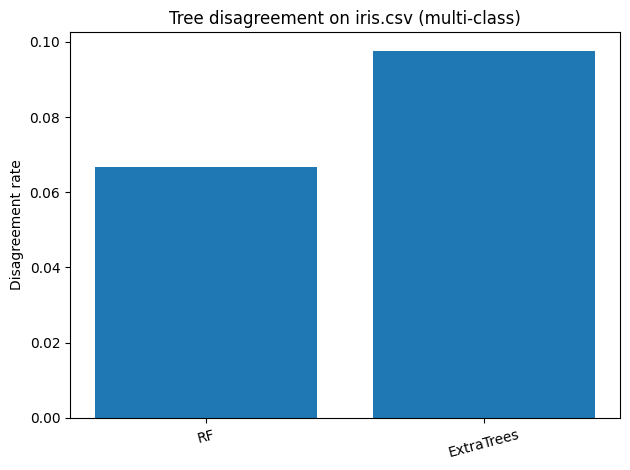

RF disagreement: 0.06684633269921791
ExtraTrees disagreement: 0.09767138730360035


In [6]:
# Load dataset (Classification: iris.csv)
df2 = safe_read_csv("../../../Datasets/Classification/iris.csv")
target2 = "classification"

summarize_df(df2, target=target2, n=5)

X2 = df2.drop(columns=[target2])
y2 = df2[target2]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.25, random_state=RANDOM_STATE, stratify=y2
)

num_cols2 = X2.columns.tolist()
preprocess2 = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
        ]), num_cols2),
    ],
    remainder="drop"
)

rf2 = Pipeline([
    ("prep", preprocess2),
    ("model", RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1, max_features="sqrt", bootstrap=True
    ))
])

et2 = Pipeline([
    ("prep", preprocess2),
    ("model", ExtraTreesClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1, max_features="sqrt", bootstrap=False
    ))
])

rf2.fit(X2_train, y2_train)
et2.fit(X2_train, y2_train)

def eval_multiclass(pipe, X_te, y_te, name):
    pred = pipe.predict(X_te)
    acc = accuracy_score(y_te, pred)
    f1m = f1_score(y_te, pred, average="macro")
    return {"model": name, "accuracy": acc, "f1_macro": f1m}

rf2_m = eval_multiclass(rf2, X2_test, y2_test, "RandomForest")
et2_m = eval_multiclass(et2, X2_test, y2_test, "ExtraTrees")
display(pd.DataFrame([rf2_m, et2_m]))

X2_test_p = rf2.named_steps["prep"].transform(X2_test)
rf2_dis = classification_disagreement(rf2.named_steps["model"], X2_test_p, max_pairs=1500, random_state=RANDOM_STATE)
et2_dis = classification_disagreement(et2.named_steps["model"], X2_test_p, max_pairs=1500, random_state=RANDOM_STATE)

plot_metric_bars(
    ["RF", "ExtraTrees"],
    [rf2_dis, et2_dis],
    title="Tree disagreement on iris.csv (multi-class)",
    ylabel="Disagreement rate"
)

print("RF disagreement:", rf2_dis)
print("ExtraTrees disagreement:", et2_dis)


## ۶) آزمایش ۳ — رگرسیون با ویژگی‌های ترکیبی (house-prices.csv)

در رگرسیون به معیارهایی مثل:
- $R^2$ و RMSE،
- پایداری پیش‌بینی‌ها و همبستگی بین درخت‌ها،
- و اثر آستانه‌های تصادفی بر «هموار بودن» پیش‌بینی‌ها
توجه داریم.

دیتاست `house-prices.csv` هم ویژگی عددی و هم ویژگی دسته‌ای دارد (`Brick`, `Neighborhood`).
پس یک pipeline کامل می‌سازیم (impute + one-hot برای categorical) و مقایسه می‌کنیم:
- RandomForestRegressor
- ExtraTreesRegressor


,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
0,1,114300,1790,2,2,2,No,East
1,2,114200,2030,4,2,3,No,East
2,3,114800,1740,3,2,1,No,East
3,4,94700,1980,3,2,3,No,East
4,5,119800,2130,3,3,3,No,East



Shape: (128, 8)

Target distribution:


Price
103200    2
105600    2
117800    2
129800    2
125700    2
114600    1
119800    1
94700     1
114300    1
114200    1
114800    1
123000    1
102600    1
126300    1
176800    1
145800    1
147100    1
83600     1
111400    1
167200    1
Name: count, dtype: int64

,model,rmse,r2
0,RandomForestRegressor,12518.802692,0.744346
1,ExtraTreesRegressor,14256.812139,0.668432


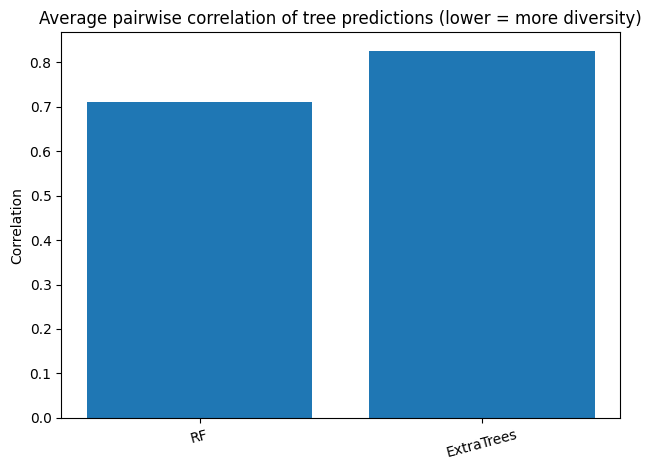

RF avg pred correlation: 0.7114666019393976
ExtraTrees avg pred correlation: 0.8263701557107731


In [7]:
# Load dataset (Regression: house-prices.csv)
df3 = safe_read_csv("../../../Datasets/Regression/house-prices.csv")
target3 = "Price"

summarize_df(df3, target=target3, n=5)

X3 = df3.drop(columns=[target3])
y3 = df3[target3]

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.25, random_state=RANDOM_STATE
)

num_cols3 = X3.select_dtypes(include=[np.number]).columns.tolist()
cat_cols3 = [c for c in X3.columns if c not in num_cols3]

preprocess3 = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
        ]), num_cols3),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols3),
    ],
    remainder="drop"
)

rfr = RandomForestRegressor(
    n_estimators=500,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    max_features=0.7,
    bootstrap=True
)
etr = ExtraTreesRegressor(
    n_estimators=500,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    max_features=0.7,
    bootstrap=False
)

rfr_pipe = Pipeline([("prep", preprocess3), ("model", rfr)])
etr_pipe = Pipeline([("prep", preprocess3), ("model", etr)])

rfr_pipe.fit(X3_train, y3_train)
etr_pipe.fit(X3_train, y3_train)

def eval_reg(pipe, X_te, y_te, name):
    pred = pipe.predict(X_te)
    return {"model": name, "rmse": rmse(y_te, pred), "r2": r2_score(y_te, pred)}

rfr_m = eval_reg(rfr_pipe, X3_test, y3_test, "RandomForestRegressor")
etr_m = eval_reg(etr_pipe, X3_test, y3_test, "ExtraTreesRegressor")
display(pd.DataFrame([rfr_m, etr_m]))

# Diversity proxy for regression: correlation among tree predictions on test set
X3_test_p = rfr_pipe.named_steps["prep"].transform(X3_test)

rfr_corr = regression_prediction_corr(rfr_pipe.named_steps["model"], X3_test_p, max_pairs=2000, random_state=RANDOM_STATE)
etr_corr = regression_prediction_corr(etr_pipe.named_steps["model"], X3_test_p, max_pairs=2000, random_state=RANDOM_STATE)

plot_metric_bars(
    ["RF", "ExtraTrees"],
    [rfr_corr, etr_corr],
    title="Average pairwise correlation of tree predictions (lower = more diversity)",
    ylabel="Correlation"
)

print("RF avg pred correlation:", rfr_corr)
print("ExtraTrees avg pred correlation:", etr_corr)


## ۷) تفسیرپذیری و پایداری (Interpretability)

Ensembleهای درختی ابزارهای توضیح‌دهی متعددی دارند، اما باید محدودیت‌ها را بشناسیم.

### ۷.۱ اهمیت ویژگی بر پایهٔ ناخالصی (impurity-based)
`feature_importances_` کاهش ناخالصی را جمع می‌کند. این معیار می‌تواند نسبت به:
- ویژگی‌های دسته‌ای با cardinality بالا (بعد از one-hot)،
- ویژگی‌های پیوسته با تعداد آستانه‌های زیاد
سوگیری داشته باشد.

در ExtraTrees به‌دلیل آستانه‌های تصادفی، توزیع کاهش ناخالصی می‌تواند تغییر کند؛ بنابراین importanceها ممکن است نسبت به seed حساس‌تر باشند.

### ۷.۲ اهمیت جایگشتی (Permutation Importance)
Permutation importance افت عملکرد را پس از درهم‌ریختن یک ویژگی اندازه می‌گیرد و معمولاً قابل‌اعتمادتر است، اما:
- در حضور ویژگی‌های همبسته می‌تواند ناپایدار باشد،
- به مجموعهٔ ارزیابی وابسته است.

در ادامه permutation importance را برای pipeline رگرسیون محاسبه می‌کنیم.


,feature,importance_mean,importance_std
6,Neighborhood,9127.696865,1800.106724
5,Brick,6363.184806,2161.269268
1,SqFt,1274.143779,760.956124
4,Offers,1044.317701,448.282816
2,Bedrooms,419.096672,271.627657
3,Bathrooms,286.685412,361.787552
0,Home,-371.469967,629.990554


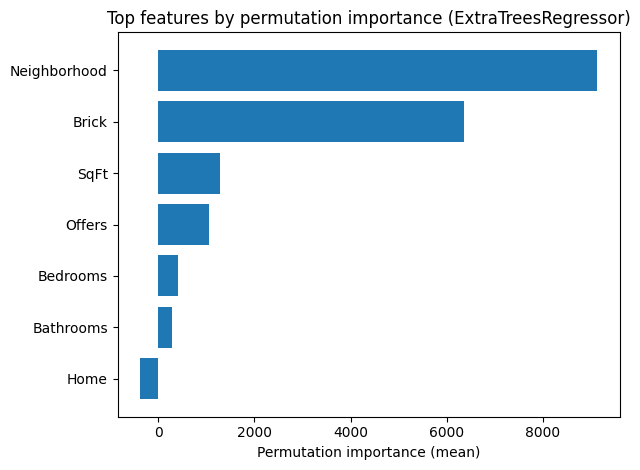

In [8]:
from sklearn.inspection import permutation_importance

# Permutation importance (two safe options)

# Option A (recommended for pipelines):
#   Run permutation importance on the *full pipeline*.
#   In this mode, sklearn permutes the ORIGINAL input columns (before one-hot/transform),
#   so the importances correspond to X3_test.columns.
result = permutation_importance(
    etr_pipe, X3_test, y3_test,
    n_repeats=15, random_state=RANDOM_STATE, n_jobs=-1,
    scoring="neg_root_mean_squared_error"
)

imp_df = pd.DataFrame({
    "feature": X3_test.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std,
}).sort_values("importance_mean", ascending=False)

display(imp_df.head(20))

# Plot top-15 (no custom colors)
topk = 15
plt.figure()
plt.barh(imp_df["feature"].head(topk)[::-1], imp_df["importance_mean"].head(topk)[::-1])
plt.xlabel("Permutation importance (mean)")
plt.title("Top features by permutation importance (ExtraTreesRegressor)")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Option B (advanced): importances on the TRANSFORMED feature space (after one-hot).
# Uncomment if you want importances for expanded one-hot columns.
#
# X3_test_p = etr_pipe.named_steps["prep"].transform(X3_test)
# feat_names = etr_pipe.named_steps["prep"].get_feature_names_out()
# result2 = permutation_importance(
#     etr_pipe.named_steps["model"], X3_test_p, y3_test,
#     n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1,
#     scoring="neg_root_mean_squared_error"
# )
# imp_df2 = pd.DataFrame({
#     "feature": feat_names,
#     "importance_mean": result2.importances_mean,
#     "importance_std": result2.importances_std,
# }).sort_values("importance_mean", ascending=False)
# display(imp_df2.head(20))


## ۸) راهنمای عملی: چه زمانی ExtraTrees را ترجیح دهیم؟

### ExtraTrees معمولاً انتخاب خوبی است اگر:
- دادهٔ شما **جدولی** و شامل تعاملات پیچیده باشد،
- احتمال واریانس بالا وجود داشته باشد (نویز، ویژگی‌های تکراری، $n$ متوسط)،
- یک baseline سریع و قوی می‌خواهید.

### Random Forest می‌تواند امن‌تر باشد اگر:
- splitهای بهینه‌تر می‌خواهید و افزایش همبستگی قابل‌پذیرش است،
- به OOB متکی هستید (با bootstrap بهتر کار می‌کند؛ ExtraTrees پیش‌فرض bootstrap ندارد اما قابل فعال‌سازی است).

### چک‌لیست تنظیمات
- `n_estimators`: آن‌قدر افزایش دهید تا منحنی اعتبارسنجی پایدار شود.
- `max_features`: کنترل تصادفی‌سازی؛ کوچک‌تر → تنوع بیشتر.
- `min_samples_leaf`: مقاوم‌سازی در برابر نویز؛ ممکن است کمی بایاس را بالا ببرد.
- `max_depth`: محدودسازی پیچیدگی.
- `bootstrap`: برای ExtraTrees اختیاری است؛ گاهی مفید.
- `class_weight`: در عدم‌توازن کلاس‌ها.

### بازتولیدپذیری
همیشه `random_state` را ثابت کنید و پروتکل ارزیابی را مستندسازی کنید.


## ۹) جمع‌بندی (نکات کلیدی)

1. ExtraTrees با **تصادفی‌سازی بیشتر** (آستانه‌های تصادفی) **همبستگی** بین درخت‌ها را کاهش می‌دهد.
2. واریانس میانگین ensemble به $M$ و $\rho$ وابسته است:

$$
\operatorname{Var}(\bar h)=\sigma^2\left(\frac{1}{M} + \rho\,\frac{M-1}{M}\right).
$$

3. کاهش همبستگی (افزایش تنوع) حتی با تعداد درخت زیاد هم می‌تواند واریانس را کم کند.
4. ExtraTrees غالباً روی مسائل جدولی پرنویز که واریانس غالب است عملکرد بسیار خوبی دارد.
5. معیارهای تجربی تنوع (disagreement/correlation) برای درک trade-off ها مفید هستند.

### تمرین‌های پیشنهادی
- آزمایش ۱ را روی `Wine_Quality.csv` تکرار کنید (مثلاً `quality` را باینری یا چندکلاسه کنید) و تنوع را مقایسه کنید.
- در ExtraTrees `bootstrap=True` را فعال کنید و OOB و disagreement را بررسی کنید.
- `max_depth` را تغییر دهید و اثر عمق بر Accuracy و disagreement را ببینید.
